Raw Column Names: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


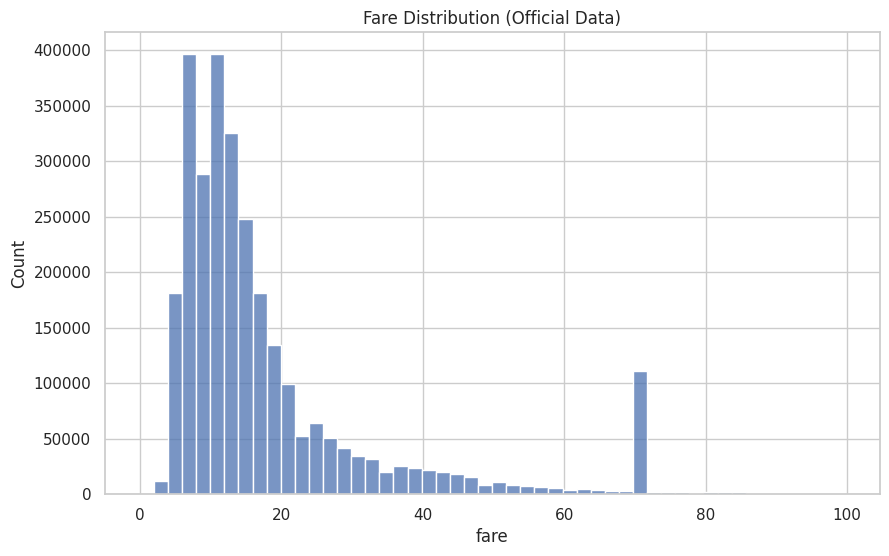

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
df = pd.read_parquet(url)

print("Raw Column Names:", df.columns.tolist())

df = df.rename(columns={
    'tpep_pickup_datetime': 'pickup',
    'tpep_dropoff_datetime': 'dropoff',
    'passenger_count': 'passengers',
    'trip_distance': 'distance',
    'fare_amount': 'fare',
    'payment_type': 'payment'
})


df['pickup'] = pd.to_datetime(df['pickup'])
df['dropoff'] = pd.to_datetime(df['dropoff'])

df_clean = df[
    (df['fare'] > 0) &
    (df['passengers'] > 0) &
    (df['distance'] > 0)
].copy()


df_clean['hour'] = df_clean['pickup'].dt.hour
df_clean['duration_min'] = (df_clean['dropoff'] - df_clean['pickup']).dt.total_seconds() / 60

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean[df_clean['fare'] < 100], x='fare', bins=50)
plt.title('Fare Distribution (Official Data)')
plt.show()

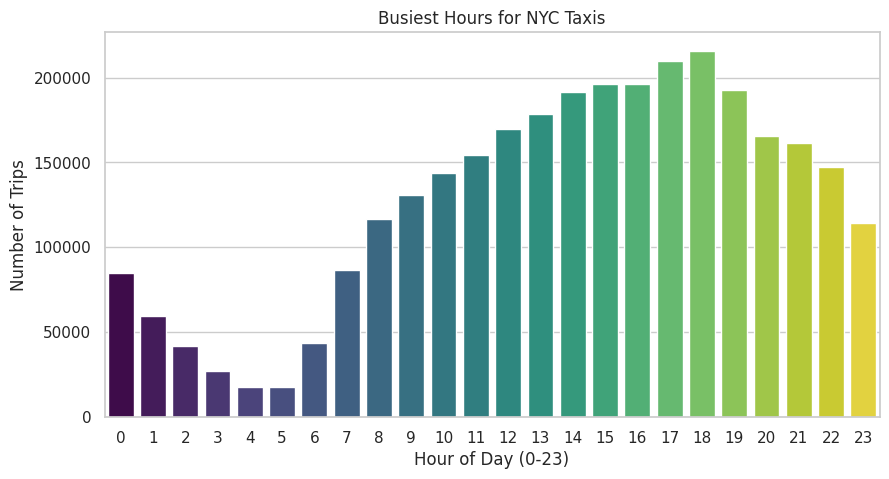

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df['hour'] = df['pickup'].dt.hour


plt.figure(figsize=(10, 5))


sns.countplot(x='hour', data=df, palette='viridis', hue='hour', legend=False)

plt.title('Busiest Hours for NYC Taxis')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trips')
plt.show()

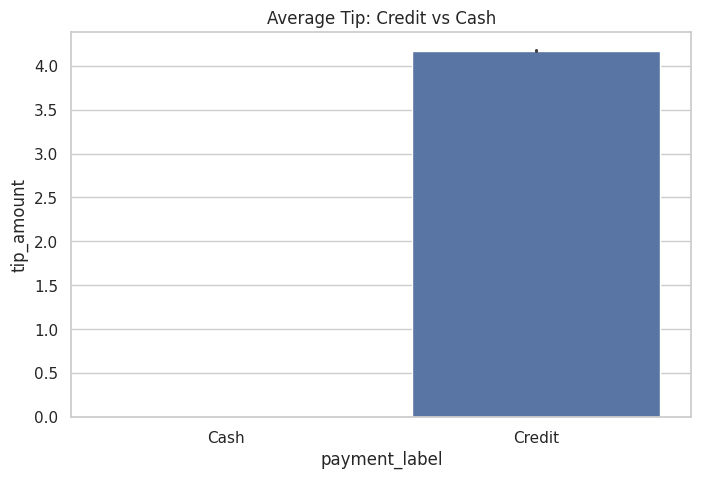

In [ ]:

# Note: 1 = Credit, 2 = Cash
payment_df = df[df['payment'].isin([1, 2])].copy()
payment_df['payment_label'] = payment_df['payment'].map({1: 'Credit', 2: 'Cash'})


plt.figure(figsize=(8, 5))
sns.barplot(x='payment_label', y='tip_amount', data=payment_df)
plt.title('Average Tip: Credit vs Cash')
plt.show()

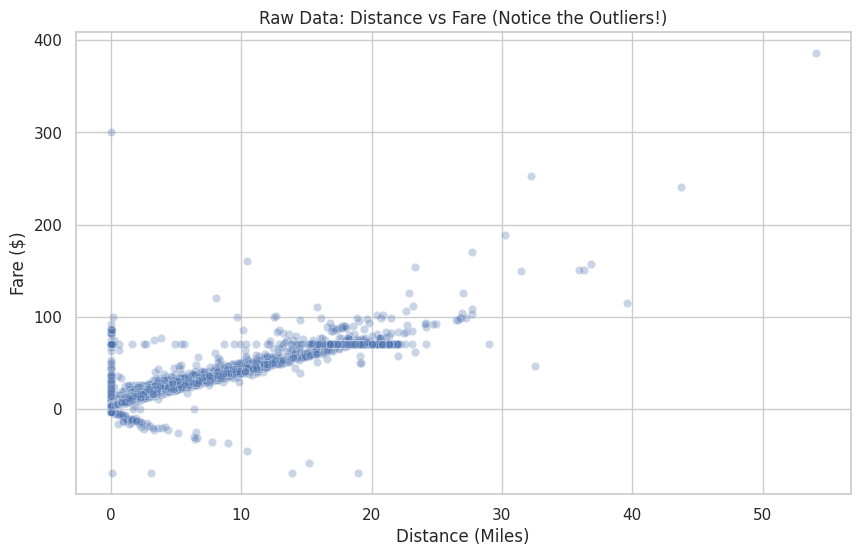

New Model Coefficient (Cost per mile): $3.61
New Base Fare (Intercept): $6.18


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare', data=df.sample(10000), alpha=0.3)
plt.title('Raw Data: Distance vs Fare (Notice the Outliers!)')
plt.xlabel('Distance (Miles)')
plt.ylabel('Fare ($)')
plt.show()

df_clean_ml = df[
    (df['distance'] > 0.5) & (df['distance'] < 50) &
    (df['fare'] >= 2.5) & (df['fare'] < 150)
].copy()


X = df_clean_ml[['distance']]
y = df_clean_ml['fare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"New Model Coefficient (Cost per mile): ${model.coef_[0]:.2f}")
print(f"New Base Fare (Intercept): ${model.intercept_:.2f}")